<a href="https://colab.research.google.com/github/DBAKALINGA/DBAKALINGA/blob/main/firsttaskformachinelearningimageclassifacation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Tunapakua picha za namba
print("Inapakua data... subiri kidogo.")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Tunatumia picha kidogo kwanza (10,000) ili iwe haraka
X_train, X_test, y_train, y_test = train_test_split(X[:10000], y[:10000], test_size=0.2)
print("Data ipo tayari!")

Inapakua data... subiri kidogo.
Data ipo tayari!


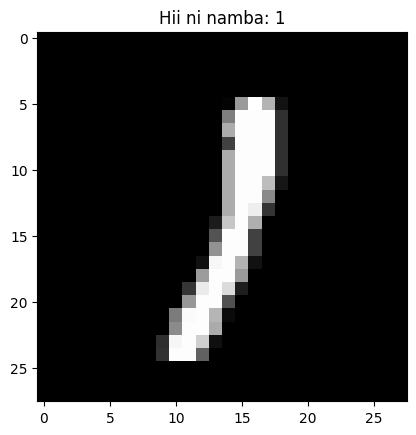

In [3]:
# Tuone picha ya kwanza
plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Hii ni namba: {y_train[0]}")
plt.show()

In [4]:
# 1. Chagua model (k=3)
model = KNeighborsClassifier(n_neighbors=3)

# 2. Fundisha model
print("Model inajifunza... subiri sekunde chache.")
model.fit(X_train, y_train)

# 3. Pima usahihi (Accuracy)
accuracy = model.score(X_test, y_test)
print(f"Usahihi wa model ni: {accuracy * 100:.2f}%")

Model inajifunza... subiri sekunde chache.
Usahihi wa model ni: 94.85%


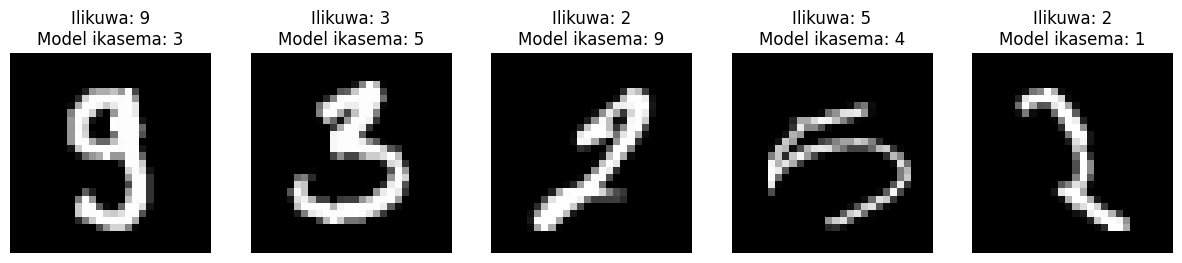

In [5]:
import numpy as np

# Tafuta sehemu ambapo model imekosea
y_pred = model.predict(X_test)
misclassified_idx = np.where(y_pred != y_test)[0]

# Onyesha picha 5 ambazo model imekosea
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, idx in enumerate(misclassified_idx[:5]):
    axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Ilikuwa: {y_test[idx]}\nModel ikasema: {y_pred[idx]}")
    axes[i].axis('off')
plt.show()

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       196
           1       0.91      1.00      0.95       230
           2       0.97      0.91      0.94       203
           3       0.93      0.91      0.92       198
           4       0.95      0.95      0.95       195
           5       0.95      0.92      0.94       173
           6       0.95      0.98      0.96       196
           7       0.95      0.95      0.95       229
           8       0.99      0.89      0.94       186
           9       0.93      0.95      0.94       194

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [10]:
import os

# Hapa tunaweka hiyo token uliyopewa kama 'environment variable'
os.environ['KAGGLE_USERNAME'] = "fraigodrichard" # Weka jina lako la Kaggle hapa
os.environ['KAGGLE_KEY'] = "61612c5d0616610c59a9de2b17668dbe"

In [11]:
!kaggle competitions download -c digit-recognizer

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [12]:
import os

# JINA_LAKO: Angalia kwenye Kaggle Settings, pameandikwa "Username"
os.environ['KAGGLE_USERNAME'] = "fraigodrichard"
# KEY: Hii ni ile namba na herufi ndefu uliyopewa (bila herufi za mwanzo 'KGAT_')
os.environ['KAGGLE_KEY'] = "61612c5d0616610c59a9de2b17668dbe"

print("Tayari! Jaribu kupakua sasa.")

Tayari! Jaribu kupakua sasa.


In [13]:
!kaggle competitions download -c digit-recognizer

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [16]:
from google.colab import files
files.upload() # Pakia lile file la kaggle.json hapa

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"fraigodrichard","key":"61612c5d0616610c59a9de2b17668dbe"}'}

In [20]:
!unzip digit-recognizer.zip

Streaming output truncated to the last 5000 lines.
  inflating: trainingSet/trainingSet/8/img_4000.jpg  
  inflating: trainingSet/trainingSet/8/img_40004.jpg  
  inflating: trainingSet/trainingSet/8/img_4001.jpg  
  inflating: trainingSet/trainingSet/8/img_40019.jpg  
  inflating: trainingSet/trainingSet/8/img_40026.jpg  
  inflating: trainingSet/trainingSet/8/img_40029.jpg  
  inflating: trainingSet/trainingSet/8/img_40032.jpg  
  inflating: trainingSet/trainingSet/8/img_40055.jpg  
  inflating: trainingSet/trainingSet/8/img_40065.jpg  
  inflating: trainingSet/trainingSet/8/img_4007.jpg  
  inflating: trainingSet/trainingSet/8/img_40109.jpg  
  inflating: trainingSet/trainingSet/8/img_40120.jpg  
  inflating: trainingSet/trainingSet/8/img_40133.jpg  
  inflating: trainingSet/trainingSet/8/img_40136.jpg  
  inflating: trainingSet/trainingSet/8/img_40150.jpg  
  inflating: trainingSet/trainingSet/8/img_40157.jpg  
  inflating: trainingSet/trainingSet/8/img_40173.jpg  
  inflating: trai

In [21]:
import os
import cv2
import numpy as np

def load_images_from_folder(base_path):
    images = []
    labels = []
    # Tunapita kwenye kila folder la namba (0 mpaka 9)
    for label in os.listdir(base_path):
        folder_path = os.path.join(base_path, label)
        if os.path.isdir(folder_path):
            print(f"Inasoma picha kutoka folder la namba: {label}")
            for filename in os.listdir(folder_path):
                img_path = os.path.join(folder_path, filename)
                # Soma picha kama grayscale (nyeusi na nyeupe)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    # Geuza picha kuwa mstari mmoja wa pixels 784 (28x28)
                    images.append(img.flatten())
                    labels.append(int(label))
    return np.array(images), np.array(labels)

# Badilisha hii 'trainingSet/trainingSet' iwe njia ya folder unaloliona pembeni
X_manual, y_manual = load_images_from_folder('trainingSet/trainingSet')
print("Usomaji umekamilika!")

Inasoma picha kutoka folder la namba: 9
Inasoma picha kutoka folder la namba: 1
Inasoma picha kutoka folder la namba: 7
Inasoma picha kutoka folder la namba: 5
Inasoma picha kutoka folder la namba: 3
Inasoma picha kutoka folder la namba: 0
Inasoma picha kutoka folder la namba: 8
Inasoma picha kutoka folder la namba: 4
Inasoma picha kutoka folder la namba: 6
Inasoma picha kutoka folder la namba: 2
Usomaji umekamilika!


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Tunagawanya data: 80% ya kufundishia, 20% ya kufanyia mtihani
X_train, X_test, y_train, y_test = train_test_split(X_manual, y_manual, test_size=0.2, random_state=42)

print(f"Data ya kufundishia (Train): {X_train.shape[0]} picha")
print(f"Data ya mtihani (Test): {X_test.shape[0]} picha")

# Tengeneza model ya k-NN (k=3)
knn_manual = KNeighborsClassifier(n_neighbors=3)

# Fundisha model
print("Model inajifunza... subiri kidogo.")
knn_manual.fit(X_train, y_train)

# Pima usahihi
accuracy = knn_manual.score(X_test, y_test)
print(f"\nUsahihi wa model yako mpya ni: {accuracy * 100:.2f}%")


Data ya kufundishia (Train): 33600 picha
Data ya mtihani (Test): 8400 picha
Model inajifunza... subiri kidogo.

Usahihi wa model yako mpya ni: 96.94%


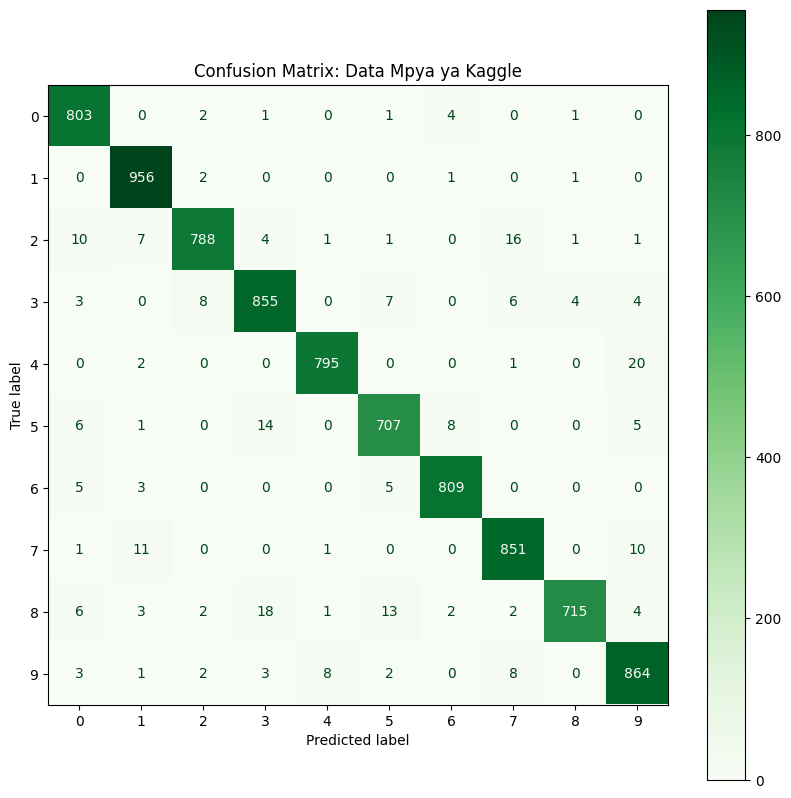

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_estimator(knn_manual, X_test, y_test, cmap='Greens', ax=ax)
plt.title("Confusion Matrix: Data Mpya ya Kaggle")
plt.show()

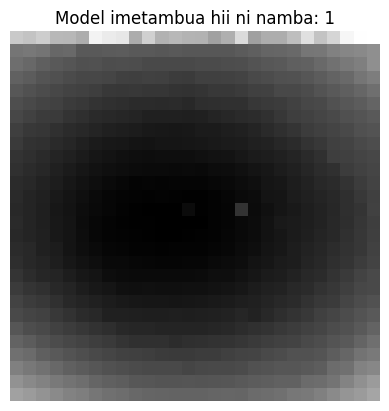

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Soma picha uliyopakia
path = 'god.jpeg' # Hakikisha jina ni sahihi!
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# 2. Geuza rangi (Kama ulitumia karatasi jeupe na wino mweusi)
# MNIST inatumia background nyeusi na namba nyeupe
img = cv2.bitwise_not(img)

# 3. Punguza ukubwa uwe 28x28 pixels
img_resized = cv2.resize(img, (28, 28))

# 4. Ifanye iwe "flat" (mstari wa namba 784)
img_flat = img_resized.flatten().reshape(1, -1)

# 5. Bashiri (Predict)
namba_iliyotabiriwa = knn_manual.predict(img_flat)

# Onyesha matokeo
plt.imshow(img_resized, cmap='gray')
plt.title(f"Model imetambua hii ni namba: {namba_iliyotabiriwa[0]}")
plt.axis('off')
plt.show()

In [15]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

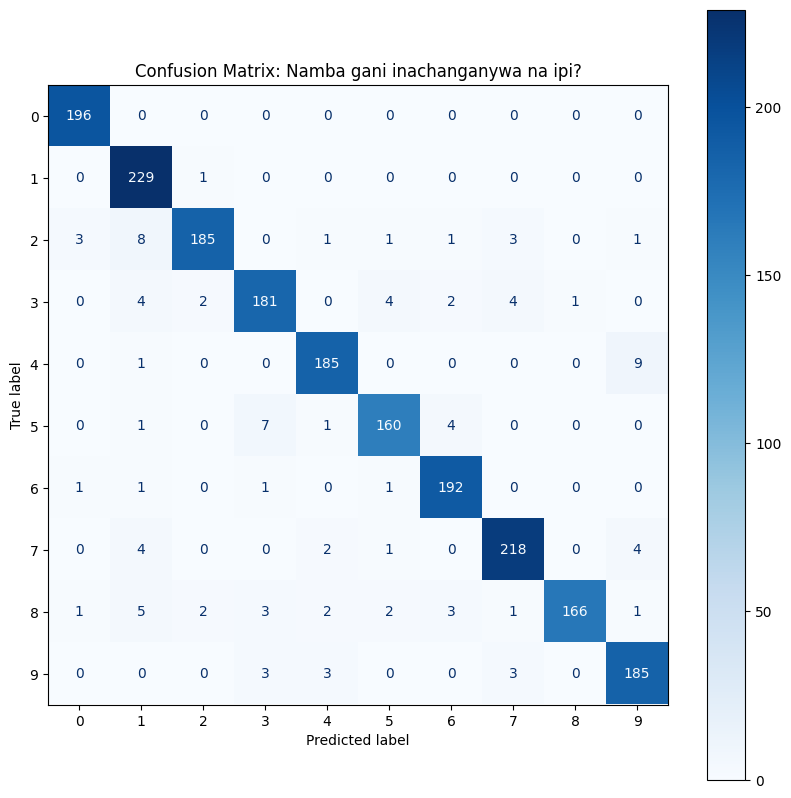

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

# Chora graph ya confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Namba gani inachanganywa na ipi?")
plt.show()